In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [2]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_scores = model.predict_proba(X_test)[:,1]


Average Precision (Original): 0.998


NameError: name 'plt' is not defined

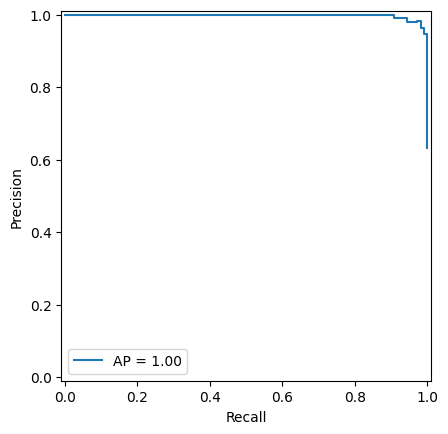

In [3]:
precision, recall, _ = precision_recall_curve(y_test, y_scores)
ap = average_precision_score(y_test, y_scores)
print(f"Average Precision (Original): {ap:.3f}")

disp = PrecisionRecallDisplay(precision=precision, recall=recall, average_precision=ap)
disp.plot()
plt.title("Precision-Recall curve (Original Data)")
plt.show()

Average Precision (Imbalanced): 0.999


NameError: name 'plt' is not defined

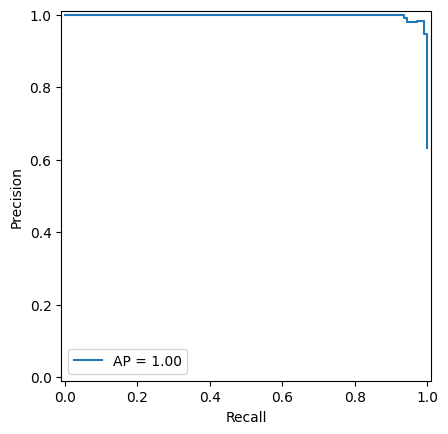

In [5]:
import numpy as np

# Find indices of positives (class 1) in the training set
positive_indices = np.where(y_train == 1)[0]

# Randomly drop 80% of positives
np.random.seed(42)
drop_indices = np.random.choice(positive_indices, size=int(0.8 * len(positive_indices)), replace=False)
y_train_imbalanced = np.delete(y_train, drop_indices)
X_train_imbalanced = np.delete(X_train, drop_indices, axis=0)

# Retrain the model on imbalanced data
model_imbalanced = RandomForestClassifier(random_state=42)
model_imbalanced.fit(X_train_imbalanced, y_train_imbalanced)

# Get predicted probabilities for class 1 (benign) on the original test set
y_scores_imbalanced = model_imbalanced.predict_proba(X_test)[:, 1]

# Compute precision-recall curve for imbalanced model
precision_imbalanced, recall_imbalanced, _ = precision_recall_curve(y_test, y_scores_imbalanced)

# Calculate Average Precision (AP) for imbalanced model
ap_imbalanced = average_precision_score(y_test, y_scores_imbalanced)
print(f"Average Precision (Imbalanced): {ap_imbalanced:.3f}")

# Plot PR curve for imbalanced model
disp_imbalanced = PrecisionRecallDisplay(precision=precision_imbalanced, recall=recall_imbalanced, average_precision=ap_imbalanced)
disp_imbalanced.plot()
plt.title("Precision-Recall Curve (Imbalanced Data - 80% Positives Dropped)")
plt.show()